# Day 3: Exploratory Data Analysis (EDA)

Setting up the environment and loading data from SQLite.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs("../reports/figures", exist_ok=True)
conn = sqlite3.connect('../data/db/bluestock_mf.db')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Task 1: NAV Trend Analysis
Plotting daily NAV for all 40 schemes and highlighting key market events.

In [2]:
# Load NAV data
query = """
SELECT nh.date, nh.nav, fm.scheme_name 
FROM nav_history nh 
JOIN fund_master fm ON nh.amfi_code = fm.amfi_code
"""
nav_df = pd.read_sql(query, conn)
nav_df['date'] = pd.to_datetime(nav_df['date'])

# Plot with Plotly
fig = px.line(nav_df, x='date', y='nav', color='scheme_name', title='NAV Trend (2022-2026)')

# Add Annotations
fig.add_annotation(x='2022-03-01', y=150, text="COVID Recovery", showarrow=True, arrowhead=1)
fig.add_annotation(x='2023-06-01', y=200, text="2023 Rally", showarrow=True, arrowhead=1)
fig.add_annotation(x='2024-03-01', y=180, text="2024 Corrections", showarrow=True, arrowhead=1)

fig.update_layout(showlegend=False) # Hide legend as it's too large for 40 schemes
fig.write_image("../reports/figures/nav_trend_lines.png")
fig.show()

## Task 2: AUM Growth Bar Chart
Grouped bar chart for AUM by fund house per year.

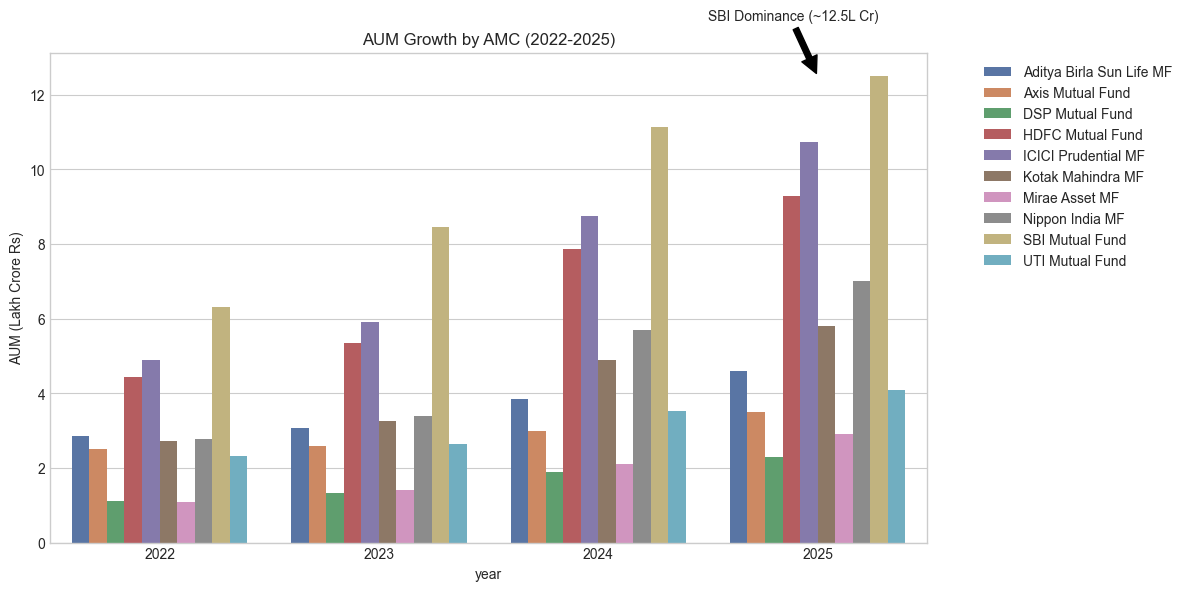

In [3]:
# Load AUM data
aum_df = pd.read_sql("SELECT date, fund_house, aum_lakh_crore FROM aum_by_fund_house", conn)
aum_df['date'] = pd.to_datetime(aum_df['date'])
aum_df['year'] = aum_df['date'].dt.year

# Get max AUM per fund house per year
yearly_aum = aum_df.groupby(['year', 'fund_house'])['aum_lakh_crore'].max().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=yearly_aum, x='year', y='aum_lakh_crore', hue='fund_house')
plt.title('AUM Growth by AMC (2022-2025)')
plt.ylabel('AUM (Lakh Crore Rs)')
plt.annotate("SBI Dominance (~12.5L Cr)", xy=(3, 12.5), xytext=(2.5, 14), 
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../reports/figures/aum_growth_amc.png", dpi=300)
plt.show()

## Task 3: SIP Inflow Time-Series
Monthly SIP inflows highlighting milestones.

In [4]:
sip_df = pd.read_sql("SELECT month, sip_inflow_crore FROM monthly_sip_inflows ORDER BY month", conn)

fig = px.line(sip_df, x='month', y='sip_inflow_crore', title='SIP Inflow Trend (2022-2025)')
fig.add_annotation(x='2025-12', y=31002, text="₹31,002 Cr All-Time High", showarrow=True, arrowhead=1)
fig.write_image("../reports/figures/sip_inflow_trend.png")
fig.show()

## Task 4: Category-Wise Inflow Heatmap
Net inflow across months by category.

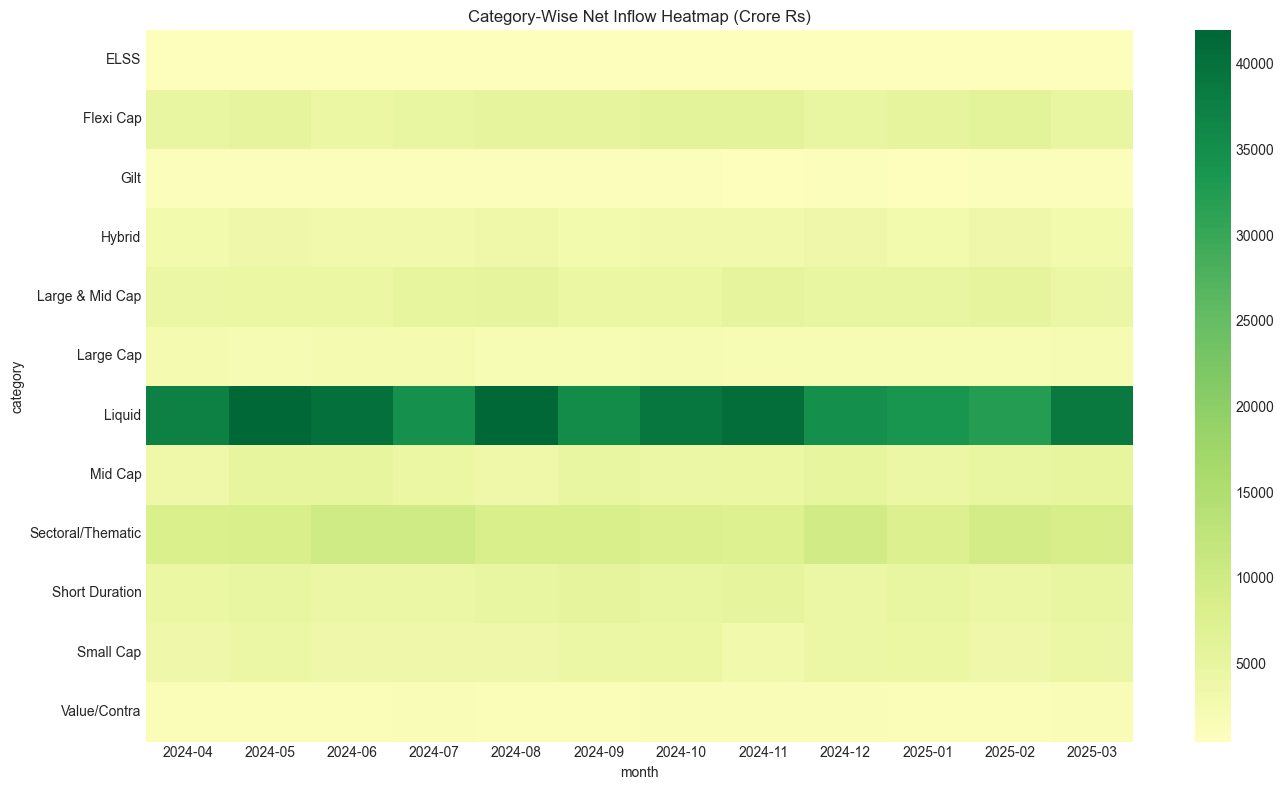

In [5]:
cat_df = pd.read_sql("SELECT month, category, net_inflow_crore FROM category_inflows", conn)
pivot = cat_df.pivot(index='category', columns='month', values='net_inflow_crore')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, cmap='RdYlGn', center=0, annot=False)
plt.title('Category-Wise Net Inflow Heatmap (Crore Rs)')
plt.tight_layout()
plt.savefig("../reports/figures/category_heatmap.png", dpi=300)
plt.show()

## Task 5: Investor Demographics
Age group and gender distribution, and SIP amounts by age.

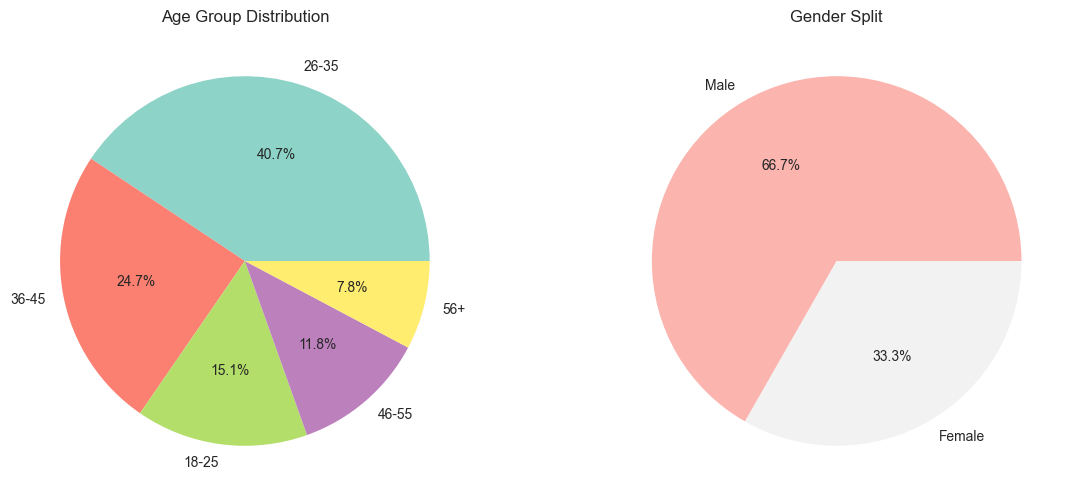

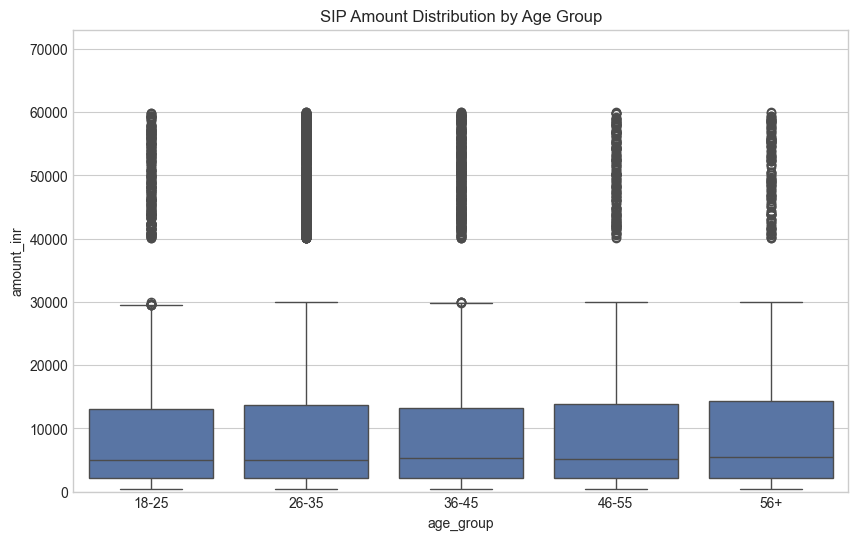

In [6]:
# Demographics
demo_df = pd.read_sql("SELECT investor_id, age_group, gender FROM fact_transactions GROUP BY investor_id", conn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
demo_df['age_group'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax1, title='Age Group Distribution', cmap='Set3')
demo_df['gender'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax2, title='Gender Split', cmap='Pastel1')
ax1.set_ylabel('')
ax2.set_ylabel('')
plt.savefig("../reports/figures/demographics_pie.png", dpi=300)
plt.show()

# Box plot for SIP amount
sip_tx = pd.read_sql("SELECT age_group, amount_inr FROM fact_transactions WHERE transaction_type='SIP'", conn)
plt.figure(figsize=(10, 6))
sns.boxplot(data=sip_tx, x='age_group', y='amount_inr', order=['18-25', '26-35', '36-45', '46-55', '56+'])
plt.title('SIP Amount Distribution by Age Group')
# Limiting Y axis to ignore extreme outliers for better visualization
plt.ylim(0, sip_tx['amount_inr'].quantile(0.95) * 1.5)
plt.savefig("../reports/figures/demographics_box.png", dpi=300)
plt.show()

## Task 6: Geographic Distribution
SIP amounts by state and T30 vs B30 analysis.

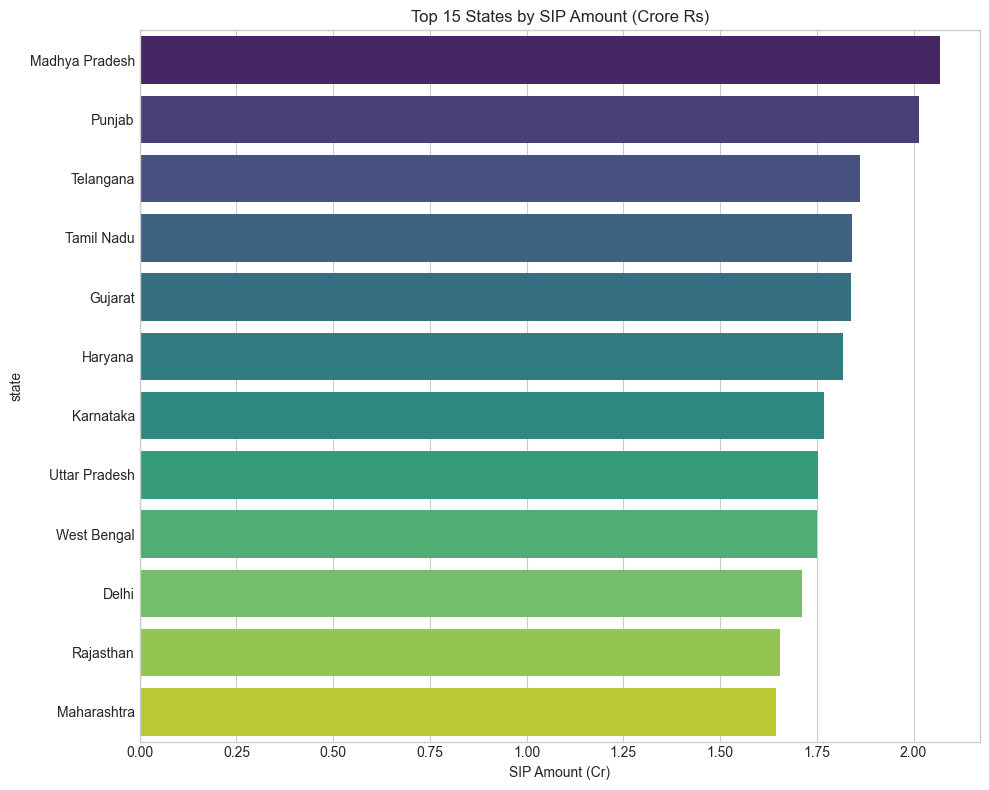

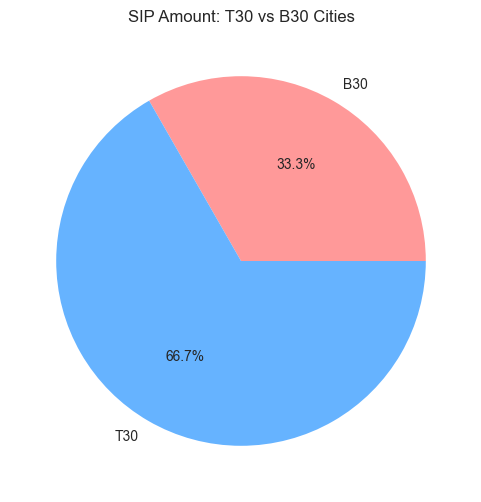

In [7]:
# State bar chart
state_df = pd.read_sql("""
SELECT state, SUM(amount_inr)/1e7 AS amount_cr 
FROM fact_transactions 
WHERE transaction_type='SIP' AND state IS NOT NULL
GROUP BY state ORDER BY amount_cr DESC LIMIT 15
""", conn)

plt.figure(figsize=(10, 8))
sns.barplot(data=state_df, y='state', x='amount_cr', orient='h', palette='viridis')
plt.title('Top 15 States by SIP Amount (Crore Rs)')
plt.xlabel('SIP Amount (Cr)')
plt.tight_layout()
plt.savefig("../reports/figures/geo_distribution_state.png", dpi=300)
plt.show()

# T30 vs B30
tier_df = pd.read_sql("""
SELECT city_tier, SUM(amount_inr) as total_amt 
FROM fact_transactions 
WHERE transaction_type='SIP' AND city_tier IS NOT NULL
GROUP BY city_tier
""", conn)

plt.figure(figsize=(6, 6))
plt.pie(tier_df['total_amt'], labels=tier_df['city_tier'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('SIP Amount: T30 vs B30 Cities')
plt.savefig("../reports/figures/geo_distribution_tier.png", dpi=300)
plt.show()